# ИССЛЕДОВАНИЕ ДАННЫХ HR-АГЕНТСТВА

HR-агентство изучает тренды на рынке труда в IT. Компания хочет провести исследование на основе данных о зарплатах в сфере Data Science за 2020–2022 годы и получить некоторые выводы.

Исследуйте данные и сделайте выводы по полученным результатам. Подкрепите свои рассуждения и выводы визуализациями и с помощью статистического тестирования проверьте, являются ли выводы статистически значимыми.

В процессе своего анализа вы должны:

Выяснить, какие факторы влияют на зарплату специалиста Data Scientist.
А также ответить на ключевые вопросы HR-агентства:
Наблюдается ли ежегодный рост зарплат у специалистов Data Scientist?
Как соотносятся зарплаты Data Scientist и Data Engineer в 2022 году?
Как соотносятся зарплаты специалистов Data Scientist в компаниях различных размеров?
Есть ли связь между наличием должностей Data Scientist и Data Engineer и размером компании?
Если вы найдёте в данных интересные закономерности, также отметьте их в своём анализе.

Продемонстрируйте использование разных тестов для проверки статистической значимости сделанных выводов:

тесты для количественного признака:
для одной выборки;
для двух выборок;
для нескольких выборок;
тест для категориальных признаков.

# Загрузка и обработка данных


Импорт библиотек

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats

In [3]:
#считываем данные
ds_salaries_data = pd.read_csv('ds_salaries.csv', index_col= 0)
ds_salaries_data

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L
...,...,...,...,...,...,...,...,...,...,...,...
602,2022,SE,FT,Data Engineer,154000,USD,154000,US,100,US,M
603,2022,SE,FT,Data Engineer,126000,USD,126000,US,100,US,M
604,2022,SE,FT,Data Analyst,129000,USD,129000,US,0,US,M
605,2022,SE,FT,Data Analyst,150000,USD,150000,US,100,US,M


In [4]:
ds_salaries_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 607 entries, 0 to 606
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           607 non-null    int64 
 1   experience_level    607 non-null    object
 2   employment_type     607 non-null    object
 3   job_title           607 non-null    object
 4   salary              607 non-null    int64 
 5   salary_currency     607 non-null    object
 6   salary_in_usd       607 non-null    int64 
 7   employee_residence  607 non-null    object
 8   remote_ratio        607 non-null    int64 
 9   company_location    607 non-null    object
 10  company_size        607 non-null    object
dtypes: int64(4), object(7)
memory usage: 56.9+ KB


Типы данных столбцов корректны.

In [5]:
#проверяем на пропуски
ds_salaries_data.isnull().mean()

work_year             0.0
experience_level      0.0
employment_type       0.0
job_title             0.0
salary                0.0
salary_currency       0.0
salary_in_usd         0.0
employee_residence    0.0
remote_ratio          0.0
company_location      0.0
company_size          0.0
dtype: float64

Пропусков нет.

In [6]:
#проверяем на дупликаты
ds_salaries_data.duplicated().sum()

42

Дупликатов есть.

In [7]:
#удаляем дубликаты
ds_salaries_data = ds_salaries_data.drop_duplicates()

In [8]:
ds_salaries_data.duplicated().sum()

0

Дубликаты удалены.

Отфильтруем данные и оставим информацию только о должностях data scientist и data engineer. 

In [9]:
#делаю копию исходных данных
ds_salaries_data_copy = ds_salaries_data.copy()

In [10]:
#Фильтрую
ds_salaries_data = ds_salaries_data[(ds_salaries_data.job_title == 'Data Scientist') | (ds_salaries_data.job_title == 'Data Engineer')]
ds_salaries_data

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
7,2020,MI,FT,Data Scientist,11000000,HUF,35735,HU,50,HU,L
10,2020,EN,FT,Data Scientist,45000,EUR,51321,FR,0,FR,S
11,2020,MI,FT,Data Scientist,3000000,INR,40481,IN,0,IN,L
12,2020,EN,FT,Data Scientist,35000,EUR,39916,FR,0,FR,M
...,...,...,...,...,...,...,...,...,...,...,...
593,2022,SE,FT,Data Scientist,150000,USD,150000,US,100,US,M
598,2022,MI,FT,Data Scientist,160000,USD,160000,US,100,US,M
599,2022,MI,FT,Data Scientist,130000,USD,130000,US,100,US,M
602,2022,SE,FT,Data Engineer,154000,USD,154000,US,100,US,M


<Axes: >

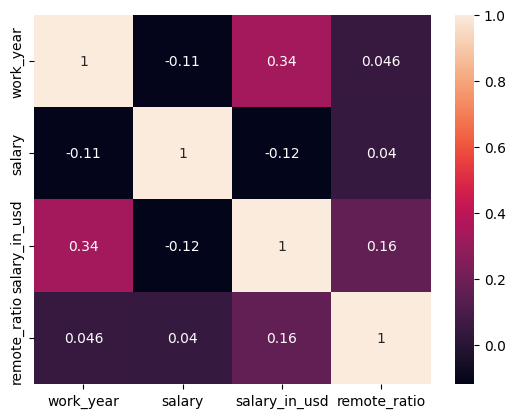

In [11]:
#составляю тепловую карту кореляций
sns.heatmap(ds_salaries_data.corr(numeric_only=True), annot = True)

Высокой корелляции между признаками не наблюдается. 

In [12]:
#удаляю ненужные столбцы
ds_salaries_data = ds_salaries_data.drop(columns = ['salary', 'salary_currency', 'employee_residence'], axis = 1)

Удалил признаки зарплаты и валюты, так как у нас для них есть общий признак "зарплата в долларах". Также удалил признак "страна проживания сотрудника", так как заработная плата выплачивается компанией и нам важно ее геолокаиця.

In [13]:
ds_salaries_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 251 entries, 0 to 603
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   work_year         251 non-null    int64 
 1   experience_level  251 non-null    object
 2   employment_type   251 non-null    object
 3   job_title         251 non-null    object
 4   salary_in_usd     251 non-null    int64 
 5   remote_ratio      251 non-null    int64 
 6   company_location  251 non-null    object
 7   company_size      251 non-null    object
dtypes: int64(3), object(5)
memory usage: 17.6+ KB


Числовыми признаками у нас являются: год, зарплата (в долларах), процент работы, выполненной удаленно.

Категориальные признаки: уровень опыта, тип устройства на работу, название должности, расположение компании и размер компании.

# РАЗВЕДЫВАТЕЛЬНЫЙ АНАЛИЗ

# Визуальный

Text(0.5, 1.0, 'Гистограмма распределения зарплат')

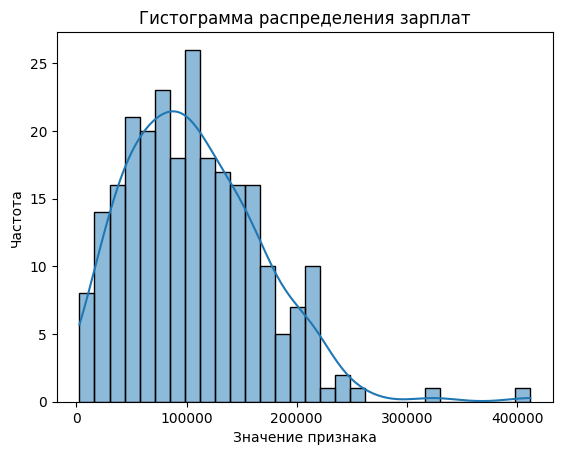

In [14]:
#строю гистограмму распределения зарплат
ax = sns.histplot(ds_salaries_data['salary_in_usd'], bins=30, kde=True)
ax.set(xlabel='Значение признака', ylabel='Частота')
plt.title('Гистограмма распределения зарплат')

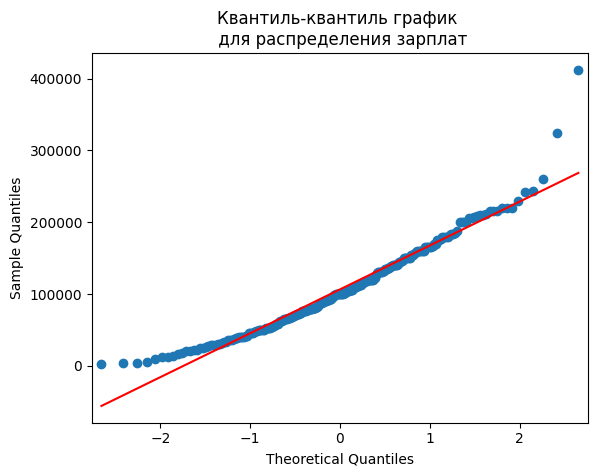

In [15]:
#строю квантиль квантиль график
sm.qqplot(ds_salaries_data['salary_in_usd'], line='s')
plt.title('Квантиль-квантиль график \n для распределения зарплат')
plt.show()

Зарплаты распределны ненормально.

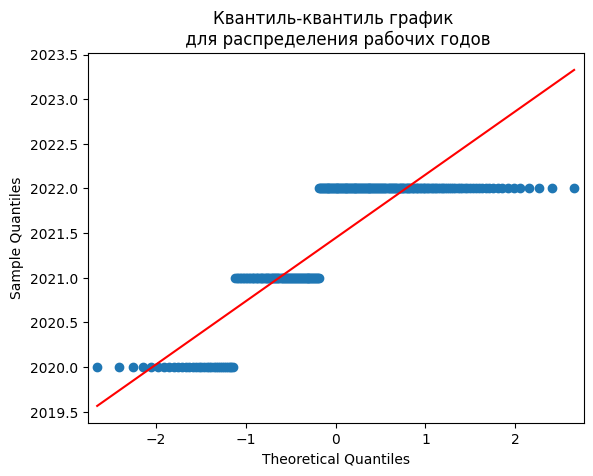

In [16]:
#строю квантиль квантиль график
sm.qqplot(ds_salaries_data['work_year'], line='s')
plt.title('Квантиль-квантиль график \n для распределения рабочих годов')
plt.show()

Text(0.5, 1.0, 'Гистограмма распределения рабочих годов')

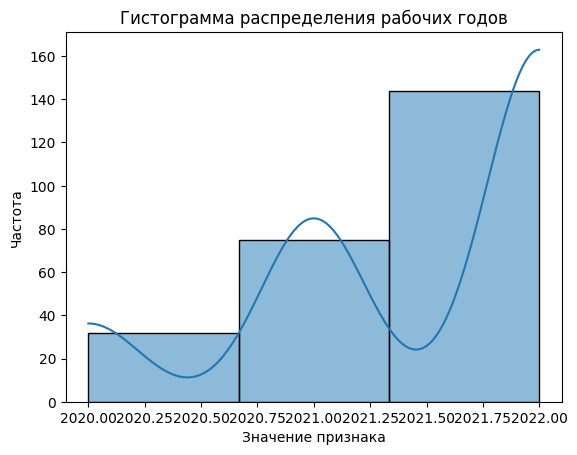

In [17]:
#строю гистограмму распределения
ax = sns.histplot(ds_salaries_data['work_year'], bins=3, kde=True)
ax.set(xlabel='Значение признака', ylabel='Частота')
plt.title('Гистограмма распределения рабочих годов')

Года распределены ненормально.

Text(0.5, 1.0, 'Гистограмма распределения процента работы, выполненной удаленно')

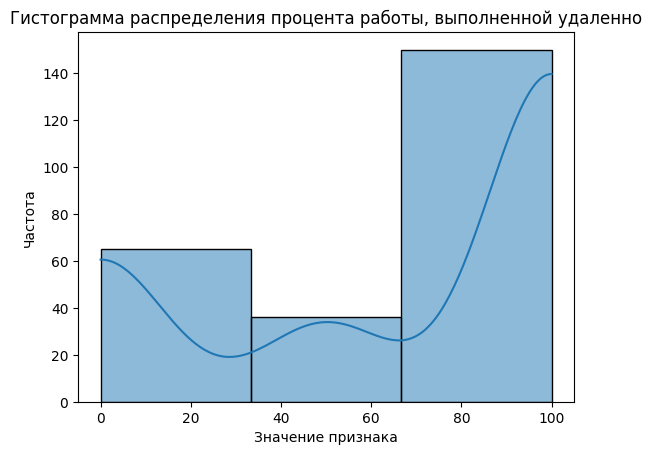

In [18]:
#строю гистограмму распределения
ax = sns.histplot(ds_salaries_data['remote_ratio'], bins=3, kde=True)
ax.set(xlabel='Значение признака', ylabel='Частота')
plt.title('Гистограмма распределения процента работы, выполненной удаленно')

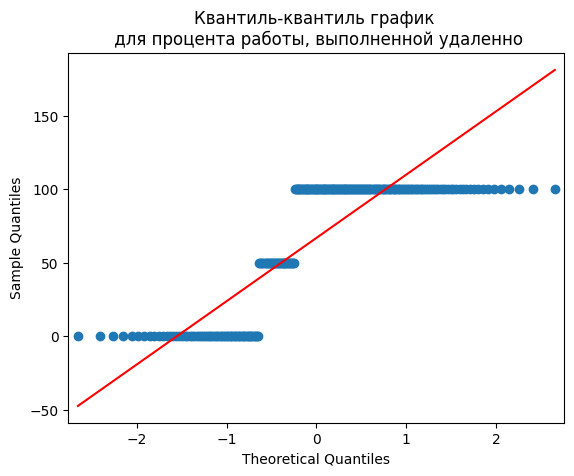

In [19]:
#строю квантиль квантиль график
sm.qqplot(ds_salaries_data['remote_ratio'], line='s')
plt.title('Квантиль-квантиль график \n для процента работы, выполненной удаленно')
plt.show()

Распределение признака "процент работы, выполненной удаленно" ненормально.

Text(0.5, 1.0, 'График соотношения опыта работы и количества записей в таблице')

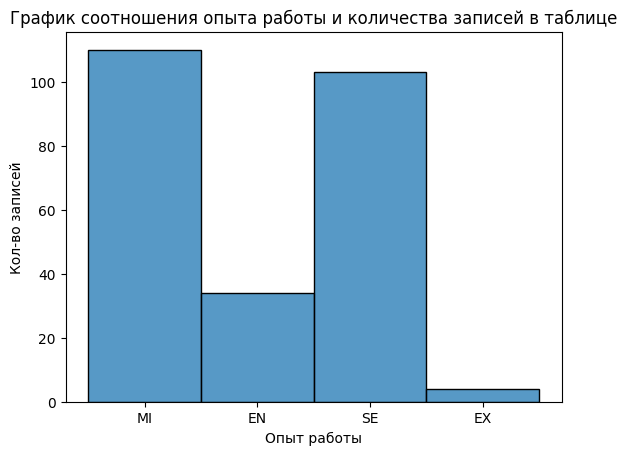

In [20]:
#График соотношения опыта работы и количества записей в таблице
grapth = sns.histplot(ds_salaries_data['experience_level'])
grapth.set(xlabel= 'Опыт работы', ylabel= 'Кол-во записей')
plt.title('График соотношения опыта работы и количества записей в таблице')

Text(0.5, 1.0, 'График соотношения Тип трудоустройства и количества записей в таблице')

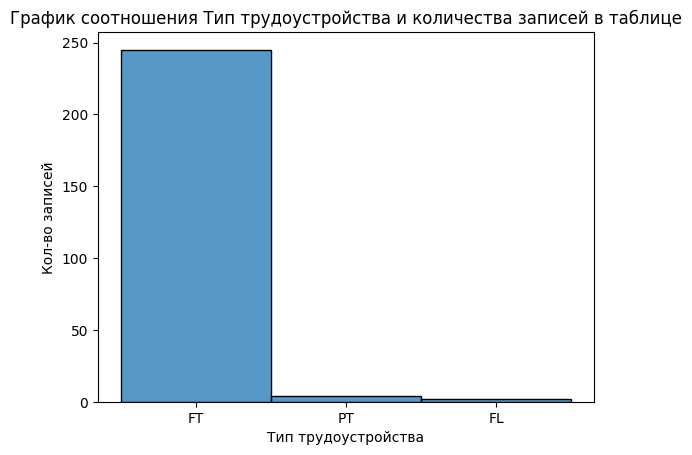

In [21]:
#График соотношения Тип трудоустройства и количества записей в таблице
grapth = sns.histplot(ds_salaries_data['employment_type'])
grapth.set(xlabel= 'Тип трудоустройства', ylabel= 'Кол-во записей')
plt.title('График соотношения Тип трудоустройства и количества записей в таблице')

Text(0.5, 1.0, 'График соотношения Страна главного офиса работодателя и количества записей в таблице')

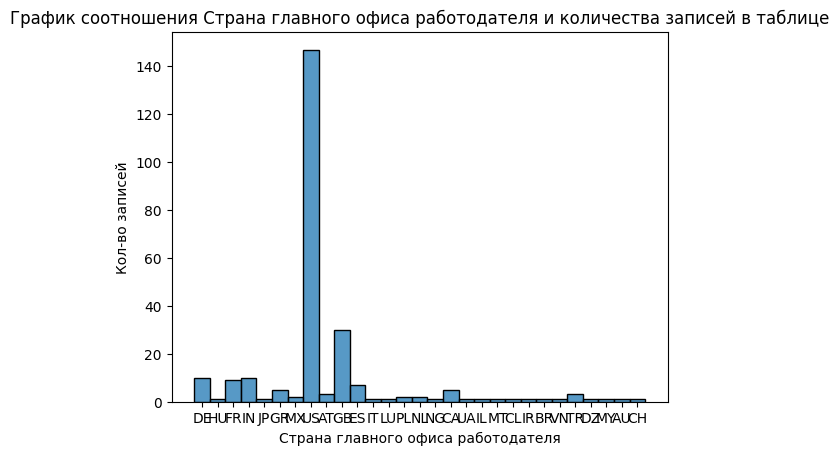

In [22]:
#График соотношения Страна главного офиса работодателя и количества записей в таблице
grapth = sns.histplot(ds_salaries_data['company_location'])
grapth.set(xlabel= 'Страна главного офиса работодателя', ylabel= 'Кол-во записей')
plt.title('График соотношения Страна главного офиса работодателя и количества записей в таблице')


Text(0.5, 1.0, 'График соотношения Среднее количество людей, работавших в компании в течение года и количества записей в таблице')

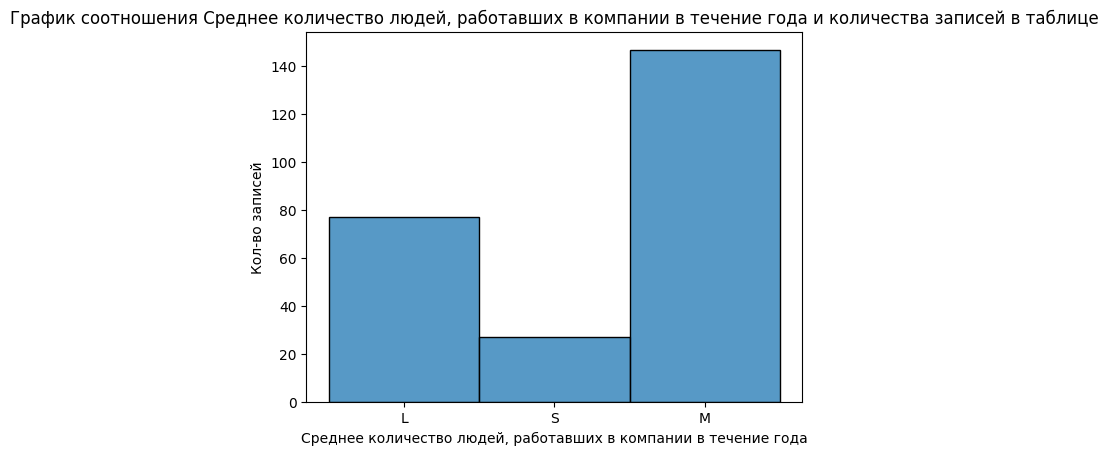

In [23]:
#График соотношения Среднее количество людей, работавших в компании в течение года и количества записей в таблице
grapth = sns.histplot(ds_salaries_data['company_size'])
grapth.set(xlabel= 'Среднее количество людей, работавших в компании в течение года', ylabel= 'Кол-во записей')
plt.title('График соотношения Среднее количество людей, работавших в компании в течение года и количества записей в таблице')


In [24]:
#создал доп. dataframe с информацией чисто по data scientist
ds_salaries_data_ds_only = ds_salaries_data[(ds_salaries_data.job_title == 'Data Scientist')]
ds_salaries_data_ds_only

,work_year,experience_level,employment_type,job_title,salary_in_usd,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,79833,0,DE,L
7,2020,MI,FT,Data Scientist,35735,50,HU,L
10,2020,EN,FT,Data Scientist,51321,0,FR,S
11,2020,MI,FT,Data Scientist,40481,0,IN,L
12,2020,EN,FT,Data Scientist,39916,0,FR,M
...,...,...,...,...,...,...,...,...
559,2022,SE,FT,Data Scientist,140400,0,US,M
570,2022,SE,FT,Data Scientist,210000,100,US,M
593,2022,SE,FT,Data Scientist,150000,100,US,M
598,2022,MI,FT,Data Scientist,160000,100,US,M


Text(0.5, 1.0, 'График соотношения опыта работы и ЗП')

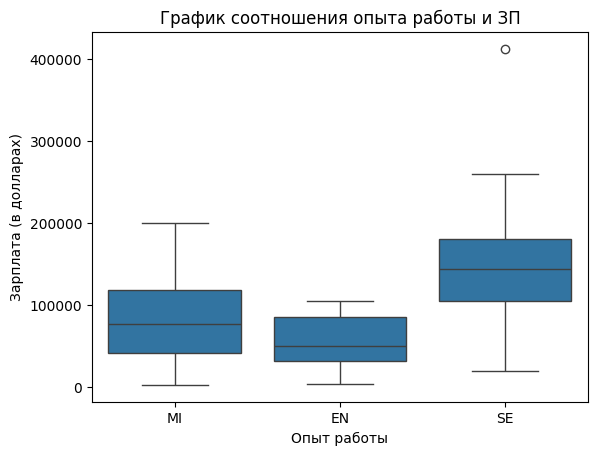

In [25]:
#построил коробчатую диограмму
graph = sns.boxplot(y = ds_salaries_data_ds_only['salary_in_usd'], x = ds_salaries_data_ds_only['experience_level'])
graph.set(ylabel= 'Зарплата (в долларах)', xlabel='Опыт работы')
plt.title('График соотношения опыта работы и ЗП')

Предварительно, исходя из графика, опыт работы влияет на уровень ЗП.

Text(0.5, 1.0, 'График Тип трудоустройства и ЗП')

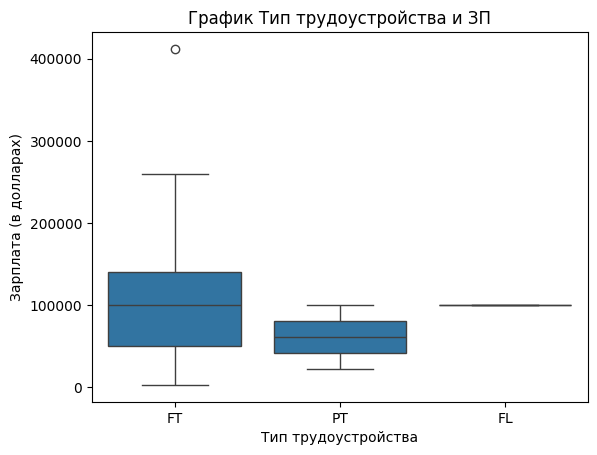

In [26]:
#построил коробчатую диограмму
graph = sns.boxplot(y = ds_salaries_data_ds_only['salary_in_usd'], x = ds_salaries_data_ds_only['employment_type'])
graph.set(ylabel= 'Зарплата (в долларах)', xlabel='Тип трудоустройства')
plt.title('График Тип трудоустройства и ЗП')

Предварительно, тип трудоустройства также влияет на зп.

Text(0.5, 1.0, 'График Год и ЗП')

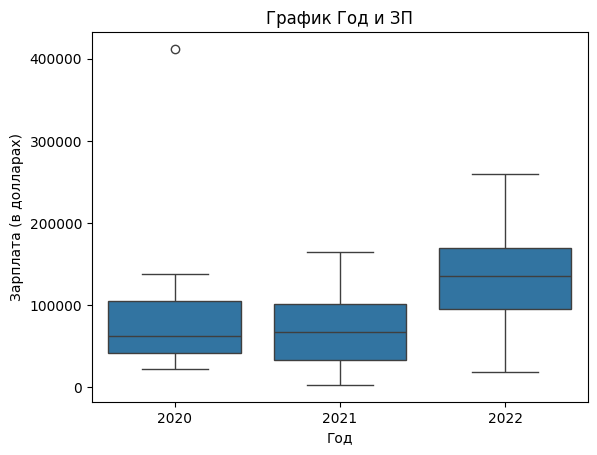

In [27]:
#построил коробчатую диограмму
graph = sns.boxplot(y = ds_salaries_data_ds_only['salary_in_usd'], x = ds_salaries_data_ds_only['work_year'])
graph.set(ylabel= 'Зарплата (в долларах)', xlabel='Год')
plt.title('График Год и ЗП')

Также, год влияет на зп, и судя по всему, с каждым годом зп становится выше.

Text(0.5, 1.0, 'График Общий объём работы, выполняемой удалённо и ЗП')

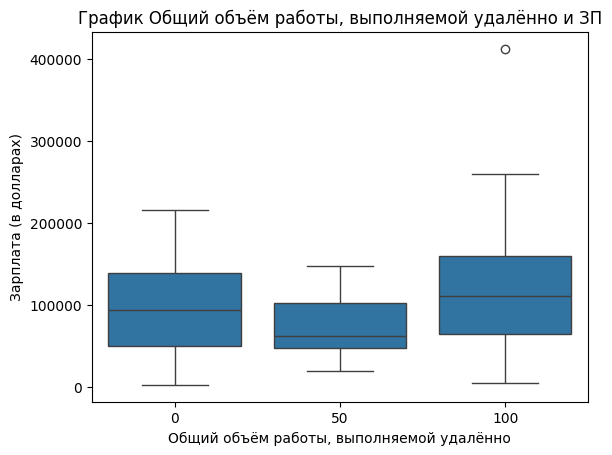

In [28]:
#построил коробчатую диограмму
graph = sns.boxplot(y = ds_salaries_data_ds_only['salary_in_usd'], x = ds_salaries_data_ds_only['remote_ratio'])
graph.set(ylabel= 'Зарплата (в долларах)', xlabel='Общий объём работы, выполняемой удалённо')
plt.title('График Общий объём работы, выполняемой удалённо и ЗП')

Также объем работы, выполняемый удаленно, влияет на зп.

Text(0.5, 1.0, 'График Страна главного офиса работодателя и ЗП')

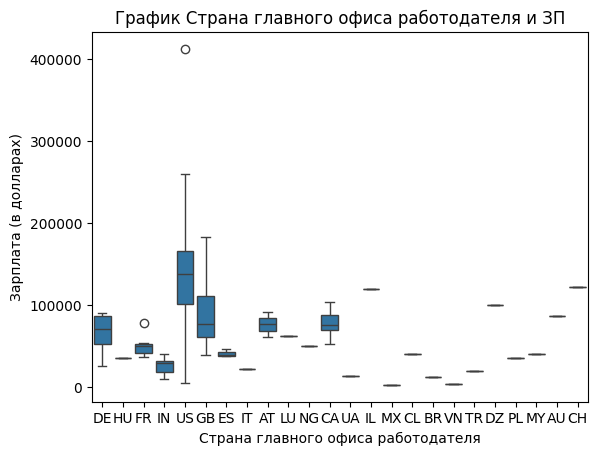

In [29]:
#построил коробчатую диограмму
graph = sns.boxplot(y = ds_salaries_data_ds_only['salary_in_usd'], x = ds_salaries_data_ds_only['company_location'])
graph.set(ylabel= 'Зарплата (в долларах)', xlabel='Страна главного офиса работодателя')
plt.title('График Страна главного офиса работодателя и ЗП')

Страна также влияет на зп.

Text(0.5, 1.0, 'График Размер компании и ЗП')

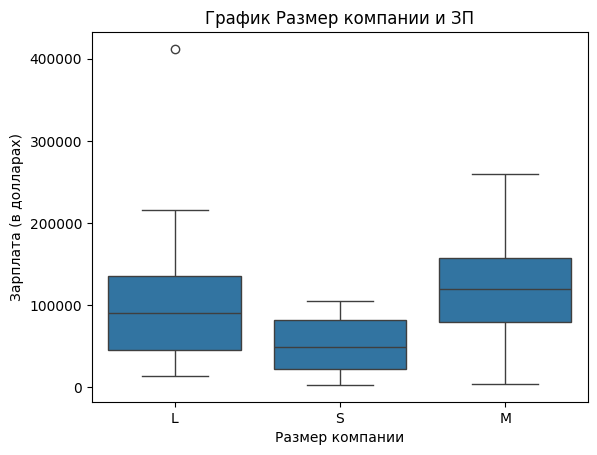

In [30]:
#построил коробчатую диограмму
graph = sns.boxplot(y = ds_salaries_data_ds_only['salary_in_usd'], x = ds_salaries_data_ds_only['company_size'])
graph.set(ylabel= 'Зарплата (в долларах)', xlabel='Размер компании')
plt.title('График Размер компании и ЗП')

Размер компании влияет на зп.

Итого, предварительно, на зарплату влияют все оставленные признаки: год,процент работы, выполненной удаленно, уровень опыта, тип устройства на работу, название должности, расположение компании и размер компании.

# Статистический анализ данных

In [31]:
#уровень значимости
alpha= 0.05

Наблюдается ли ежегодный рост зарплат у специалистов Data Scientist. 

In [32]:
#создал выборки
data_2020 = ds_salaries_data_ds_only['salary_in_usd'][ds_salaries_data_ds_only.work_year == 2020].to_numpy()
data_2021 = ds_salaries_data_ds_only['salary_in_usd'][ds_salaries_data_ds_only.work_year == 2021].to_numpy()
data_2022 = ds_salaries_data_ds_only['salary_in_usd'][ds_salaries_data_ds_only.work_year == 2022].to_numpy()


In [33]:
#проверка на нормальное распределение 

_, p = stats.shapiro(data_2020)

print(' для 2020 p-value = %.2f' % (p))

# интерпретирую результат
if p <= alpha:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')

_, p = stats.shapiro(data_2021)

print(' для 2021 p-value = %.2f' % (p))

# интерпретирую результат
if p <= alpha:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')

_, p = stats.shapiro(data_2022)

print(' для 2022 p-value = %.2f' % (p))

# интерпретирую результат
if p <= alpha:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')

 для 2020 p-value = 0.00
Распределение не нормальное
 для 2021 p-value = 0.11
Распределение нормальное
 для 2022 p-value = 0.68
Распределение нормальное


In [34]:
#проверяю количество данных
print(len(data_2020))
print(len(data_2021))
print(len(data_2022))


21
44
65


Отсюда делаем вывод, что от списка с зарплатами в 2020 году можно отказаться. Так как выборки независимы и их 2, также они нормально распрдеелены, воспользуемся двувыборочным t критерием

Нулевая гипотеза-m1>=m2
Альтернативная-m1<m2

In [35]:
#проверил равенство дисперсий
print('Тест на равенство дисперсий')
result = stats.levene(data_2021, data_2022)
p = result[1]
print('p-value = {:.3f}'.format(p))

# интерпретирую результат
if p <= alpha:
    print('Дисперсии не одинаковы, в stats.ttest_ind нужно использовать параметр equal_var=False.')
else:
    print('Дисперсии одинаковы, в stats.ttest_ind нужно использовать параметр equal_var=True.')


Тест на равенство дисперсий
p-value = 0.264
Дисперсии одинаковы, в stats.ttest_ind нужно использовать параметр equal_var=True.


In [36]:
#тест
_, p = stats.ttest_ind(data_2021, data_2022, alternative= 'less', equal_var= True)
print('p-value = {:.3f}'.format(p))
if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


Нулевую теорию отвергаем. Зарплата растет с каждым годом.

Как соотносятся зарплаты Data Scientist и Data Engineer в 2022 году?

In [37]:
#составляю выборки
data_ds = ds_salaries_data['salary_in_usd'][(ds_salaries_data['work_year']==2022) & (ds_salaries_data['job_title']=='Data Scientist')]
data_de = ds_salaries_data['salary_in_usd'][(ds_salaries_data['work_year']==2022) & (ds_salaries_data['job_title']=='Data Engineer')]



In [38]:
#проверяю на нормальное распределение
_, p = stats.shapiro(data_ds)

print(' для Data Scientist p-value = %.2f' % (p))

# интерпретируем результат
if p <= alpha:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')

 для Data Scientist p-value = 0.68
Распределение нормальное


In [39]:
#проверяю на нормальное распределение
_, p = stats.shapiro(data_de)

print(' для Data Engineer p-value = %.2f' % (p))

# интерпретируем результат
if p <= alpha:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')

 для Data Engineer p-value = 0.01
Распределение не нормальное


Распределние ненормальное. Выборки две. Они независимы. Используем U-критерий Манна-Уитни.

Нулевая гипотеза-m1=m2, зарплаты равны
Альтернативная-m1!=m2, зарплаты разные

In [40]:
#тест
_, p = stats.mannwhitneyu(data_ds, data_de)

print('p-value = {:.3f}'.format(p))

# интерпретируем результат
if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.319
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.


У нас нет оснований отвергнуть нулевую гипотезу. То есть зарплаты равны.

Как соотносятся зарплаты специалистов Data Scientist в компаниях различных размеров?

In [41]:
#строю выборки
data_s =  ds_salaries_data_ds_only['salary_in_usd'][ds_salaries_data_ds_only['company_size']=='S']
data_m = ds_salaries_data_ds_only['salary_in_usd'][ds_salaries_data_ds_only['company_size']=='M']
data_l = ds_salaries_data_ds_only['salary_in_usd'][ds_salaries_data_ds_only['company_size']=='L']

In [42]:
#проверка количества записей
print(len(data_s))
print(len(data_m))
print(len(data_l))

21
66
43


In [43]:
#проверка на нормальное распределение
_, p = stats.shapiro(data_s)

print(' для S company p-value = %.2f' % (p))

# интерпретируем результат
if p <= alpha:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')
_, p = stats.shapiro(data_m)

print(' для M company p-value = %.2f' % (p))

# интерпретируем результат
if p <= alpha:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')
_, p = stats.shapiro(data_l)

print(' для L company p-value = %.2f' % (p))

# интерпретируем результат
if p <= alpha:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')

 для S company p-value = 0.19
Распределение нормальное
 для M company p-value = 0.90
Распределение нормальное
 для L company p-value = 0.00
Распределение не нормальное


Нулевая гипотеза- m1=m2=m2
Альтернативная-m1!=m2!=m3

In [44]:
#тест
_, p = stats.kruskal(data_s, data_m, data_l)

print('p-value = {:.3f}'.format(p))

# интерпретируем результат
if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


Зарплаты различаются.

Так как количество записей с малеьнкими компаниями невелико, лучше будет отбросить эти данные и сравнить компании средние и большие.

Две выборки. Независимые. Одна ненормально распределена. Используем U-критерий. 

Нулевая гипотеза- m1<=m2 зарплата в больших компаниях больше или равна
Альтернативная-m1>m2 зарплата в больших компаниях меньше

In [45]:
#тест
_, p = stats.mannwhitneyu(data_m, data_l, alternative='greater')

print('p-value = {:.3f}'.format(p))

# интерпретируем результат
if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.024
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


Получается чем меньше компания, тем больше зп.

Есть ли связь между наличием должностей Data Scientist и Data Engineer и размером компании?

In [46]:
#составляю выборки
ds_salaries_data_copy['is_ds'] = ds_salaries_data_copy['job_title'].apply(lambda x: 'Есть' if x=='Data Scientist' or x == 'Data Engineer' else 'Нет')


In [47]:
#таблица сопряженностей
data_cross = pd.crosstab(ds_salaries_data_copy['is_ds'], ds_salaries_data_copy['company_size'])
data_cross

company_size,L,M,S
is_ds,,,
Есть,77,147,27
Нет,116,143,55


Нулевая гипотеза-признаки "наличие должности" и "размер компании"  не связаны
Альтернативная гипотеза-признаки связаны

In [48]:
#тест
_, p, _, _ = stats.chi2_contingency(data_cross)

print('p-value = {:.3f}'.format(p))

# интерпретируем результат
if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.005
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


То есть, между признаками "размер компании" и "наличие должностей" связь есть.

Теперь проверим, какие еще факторы могут влиять на уровень зп.

Влияет ли опыт работы на уровень заработной платы Data Scientist?

In [49]:
#составляю выборки
data_en = ds_salaries_data_ds_only['salary_in_usd'][ds_salaries_data_ds_only['experience_level'] == 'EN']
data_mi = ds_salaries_data_ds_only['salary_in_usd'][ds_salaries_data_ds_only['experience_level'] == 'MI']
data_se = ds_salaries_data_ds_only['salary_in_usd'][ds_salaries_data_ds_only['experience_level'] == 'SE']
#не использую в выборе данные типа "EX" так как их крайне мало
#проверяем на нормальное распределение
_, p = stats.shapiro(data_en)

print(' для зарплаты p-value = %.2f' % (p))

# интерпретируем результат
if p <= alpha:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')

#проверяем на нормальное распределение
_, p = stats.shapiro(data_mi)

print(' для зарплаты p-value = %.2f' % (p))

# интерпретируем результат
if p <= alpha:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')

#проверяем на нормальное распределение
_, p = stats.shapiro(data_se)

print(' для зарплаты p-value = %.2f' % (p))

# интерпретируем результат
if p <= alpha:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')

 для зарплаты p-value = 0.17
Распределение нормальное
 для зарплаты p-value = 0.15
Распределение нормальное
 для зарплаты p-value = 0.00
Распределение не нормальное


In [50]:
#проверка количества записей
print(len(data_en))
print(len(data_mi))
print(len(data_se))

22
59
49


Так как записей  о джунах гораздо меньше, их также отбросим в тестах.

Два признака независимы. Один распределен ненормально. Выбираем U-критерий.

Нулевая гипотеза-m1>=m2 меньше опыт, такая же или больше зп
Альтернативная гиоптеза-m1<m2 больше опыт, больше зп

In [51]:
#тест
_, p = stats.mannwhitneyu(data_mi, data_se, alternative='less')
print('p-value = {:.3f}'.format(p))

# интерпретируем результат
if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


Получается, чем больше опыт, тем больше зп.

Также на данном моменте я понял, что нам не нужен признак "тип трудоустройства", так как есть более общий признак "процент работы, выполненной удаленно".

In [52]:
#удаляю столбец employment_type
ds_salaries_data_ds_only = ds_salaries_data_ds_only.drop(columns = ['employment_type'], axis  = 1)

Влияет ли процент работы, выполненной удаленно, на уровень зарплаты?

In [53]:
#на всякий случай проверяю какие значения лежат в столбце
ds_salaries_data_ds_only['remote_ratio'].unique()

array([  0,  50, 100], dtype=int64)

In [54]:
#выборки
data_0 = ds_salaries_data_ds_only['salary_in_usd'][ds_salaries_data_ds_only['remote_ratio'] == 0].to_numpy()
data_50 = ds_salaries_data_ds_only['salary_in_usd'][ds_salaries_data_ds_only['remote_ratio'] == 50].to_numpy()
data_100 = ds_salaries_data_ds_only['salary_in_usd'][ds_salaries_data_ds_only['remote_ratio'] == 100].to_numpy()

In [55]:
#проверяем количество записей
print(len(data_0))
print(len(data_50))
print(len(data_100))


38
24
68


Так как во второй выборке мало записей, от нее отказываемся

In [56]:
#проверяем выборки на нормальное распределение
_, p = stats.shapiro(data_0)

print(' для зарплаты p-value = %.2f' % (p))

# интерпретируем результат
if p <= alpha:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')

#проверяем на нормальное распределение
_, p = stats.shapiro(data_100)

print(' для зарплаты p-value = %.2f' % (p))

# интерпретируем результат
if p <= alpha:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')

 для зарплаты p-value = 0.33
Распределение нормальное
 для зарплаты p-value = 0.00
Распределение не нормальное


Группы независимые. Распределения ненормальные. Используем U-критерий.

Нулевая гипотеза-m1=m2
Альтернативаня-m1!=m2

In [57]:
#выборка
_, p = stats.mannwhitneyu(data_0, data_100)
print('p-value = {:.3f}'.format(p))

# интерпретируем результат
if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.233
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.


Получается от процента работы, выполненной удаленно, зарплата не зависит.

Зависит ли зарплата от размера компании?

In [58]:
#Соберем данные
data_salary_s = ds_salaries_data_ds_only['salary_in_usd'][ds_salaries_data_ds_only['company_size'] == 'S'].to_numpy()
data_salary_m = ds_salaries_data_ds_only['salary_in_usd'][ds_salaries_data_ds_only['company_size'] == 'M'].to_numpy()
data_salary_l = ds_salaries_data_ds_only['salary_in_usd'][ds_salaries_data_ds_only['company_size'] == 'L'].to_numpy()


In [59]:
#проверяем количество записей
print(len(data_salary_s))
print(len(data_salary_m))
print(len(data_salary_l))

21
66
43


Первую выборку отбрасываем из за малого кол-ва записей.

In [60]:
#проверяем на нормальное распределение
_, p = stats.shapiro(data_salary_m)

print(' для зарплаты p-value = %.2f' % (p))

# интерпретируем результат
if p <= alpha:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')

#проверяем на нормальное распределение
_, p = stats.shapiro(data_salary_l)

print(' для зарплаты p-value = %.2f' % (p))

# интерпретируем результат
if p <= alpha:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')


 для зарплаты p-value = 0.90
Распределение нормальное
 для зарплаты p-value = 0.00
Распределение не нормальное


Распределение одно ненормальное. Они независимы. Выбираем U-критерий.

Нулевая гипотеза-m1<=m2 чем больше компания, тем больше зп или такая же
Альтернативная-m1>m2 чем больше компания, тем меньше зп

In [61]:
_, p = stats.mannwhitneyu(data_salary_m, data_salary_l, alternative='greater')
print('p-value = {:.3f}'.format(p))

# интерпретируем результат
if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.024
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


Значит чем больше компания, тем меньше зп.

# Выводы по бизнес проблемам

1. От каких факторов зависит заработная плата Data Scientist? 
Зарплата зависит от:
-Размера компании(чем больше компания, тем меньше зарплата)
-Опыта работы(чем больше опыт, тем больше зарплата)
-Год(с каждым годом зарплата увеличивается)
2. 
    
    
    2.1. Наблюдается ли ежегодный рост зарплат у специалистов Data Scientist?
    -Наблюдается, исходя из статистических тестов, с каждым годом среднее значение зарплат растет.
    
    
    2.2. Как соотносятся зарплаты Data Scientist и Data Engineer в 2022 году?
    -Их зарплаты примерно равны, так как во время статистического теста в качестве нулевой гипотезы было предположение, что зарплаты одинаковы и после теста оказалось, что отбросить нулевую гипотезу нельзя.
    
    
    2.3. Как соотносятся зарплаты специалистов Data Scientist в компаниях различных размеров?
    -Чем больше компания, тем меньше зарплата. В качесте альтернативной гипотезы было предложено, что чем больше компания, тем меньше зарплата. Исходя из того, что нулевую гипотезу мы отбросили и альтернативная подтвердилась, делаем вышеизложенный вывод.
    
    2.4. Есть ли связь между наличием должностей Data Scientist и Data Engineer и размером компании?
    Связь есть. После стат. теста для категориальных признаков в этом мы убедились. Предполагаю, что это связь характера "больше компания-больше вероятность наличия данных должностей".
Признак "страна офиса компании" я не рассматривал, так как сама по себе страна ничего не дает. Но можно составить доп. признак, связанный со страной, чтобы составить дополнительную гипотезу.

# Доп. исследование.

По даннным издания US News, средняя зарплата IT специалиста составляет 103500 долларов. Проверим это на наших данных.

Проведем визуальный анализ.

Text(0.5, 1.0, 'Зарплата в 2022')

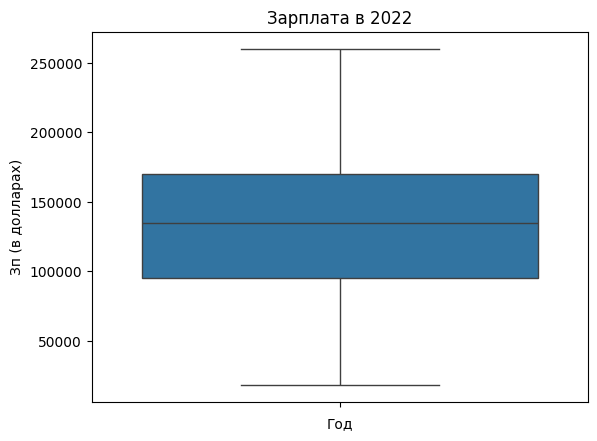

In [63]:
#коробчатая диаграмма
graph = sns.boxplot(data_2022)
graph.set(xlabel = 'Год', ylabel = 'Зп (в долларах)')
plt.title('Зарплата в 2022')

Исходя из графика, медиана зарплат существенно больше заявленой планки.
Проверим теперь это с помощью статистических тестов.

Статистический анализ

In [64]:
#проверяем на нормальное распределение
_, p = stats.shapiro(data_2022)

print(' для зарплаты p-value = %.2f' % (p))

# интерпретируем результат
if p <= alpha:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')


 для зарплаты p-value = 0.68
Распределение нормальное


Распределение нормальное. Выборка одна. Используем одновыборочный t-критерий. 

Нулевая гипотеза-m=103500
Альтернативная-m!=103500

In [65]:
#проводим тест
_, p = stats.ttest_1samp(data_2022, popmean=103500)

print('p-value = {:.3f}'.format(p))

# интерпретируем результат
if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


Предположение неверно, значит средний уровень зарплат не составляет 1035000 долларов.

Зависит ли уровень зарплат от того, находится ли сотрудник в той же стране, что и работодатель, или нет?

In [78]:
#Считаем заново данные
data_salary = pd.read_csv('ds_salaries.csv')

#Фильтруем данные
data_salary = data_salary[data_salary.job_title == 'Data Scientist']
#Добавим признак is_eq для понимания совпадают страны или нет
def is_eq_country(x, y):
    if x==y:
        return 'Да'
    else:
        return 'Нет'
data_salary['is_eq'] = data_salary.apply(lambda x:  is_eq_country(x['employee_residence'], x['company_location']), axis = 1)


Визуальный анализ

Text(0.5, 1.0, 'График соотношения совпадения стран и зарплат')

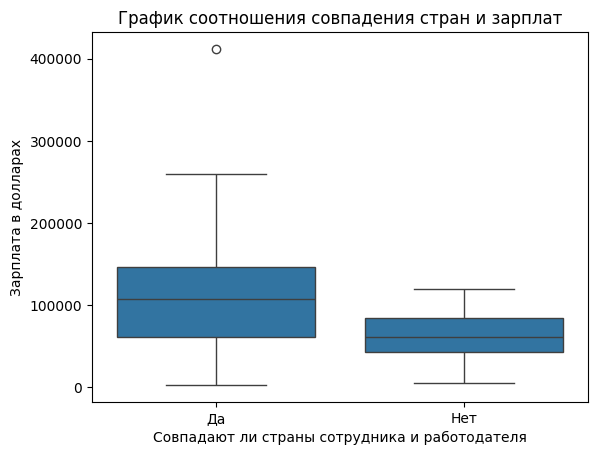

In [81]:
#График строим
graph = sns.boxplot(x = data_salary['is_eq'], y = data_salary['salary_in_usd'])
graph.set(xlabel= 'Совпадают ли страны сотрудника и работодателя', ylabel='Зарплата в долларах')
plt.title('График соотношения совпадения стран и зарплат')


Зарплаты отличаются. Исходя из графика, если страна сотрудника и компании совпадают, то зарплата выше чем в противоположном случае.

Статистический анализ

In [82]:
#Составляем выборки
data_eq = data_salary['salary_in_usd'][data_salary['is_eq']=='Да']
data_neq = data_salary['salary_in_usd'][data_salary['is_eq']=='Нет']

In [84]:

#проверяем на нормальное распределение
_, p = stats.shapiro(data_eq)

print(' для зарплаты p-value = %.2f' % (p))

# интерпретируем результат
if p <= alpha:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')

#проверяем на нормальное распределение
_, p = stats.shapiro(data_neq)

print(' для зарплаты p-value = %.2f' % (p))

# интерпретируем результат
if p <= alpha:
    print('Распределение не нормальное')
else:
    print('Распределение нормальное')

 для зарплаты p-value = 0.00
Распределение не нормальное
 для зарплаты p-value = 0.85
Распределение нормальное


Одно из распределений ненормальное. Выборки две. Они независимы. Используем U-критерий.

Нулевая гипотеза-m1<=m2 Если страны совпадают, то зарплата меньше или равна
Альтернативня гипотеза-m1>m2 Если страны совпадают, то зарплата больше

In [85]:
#проводим тест
_, p = stats.mannwhitneyu(data_eq, data_neq, alternative='greater')
print('p-value = {:.3f}'.format(p))

# интерпретируем результат
if p <= alpha:
    print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу.'.format(alpha))
else:
    print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))

p-value = 0.003
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


Подтвердили, что если страна сотрудника и компании совпадает, то зарплата выше.

Делаем выводы: исходя из проведенного анализа, средняя зарплата data scientist в 2022 году не составляет 103500 долларов, что опровергает информацию издания.
Касательно второй гипотезы, мы подтвердили, что если компания нанимает сотрудника в той же стране, то зарплата соответственно в таких случаях выше, чем в противположных.